# 03 — Witness-driven progressive search strategy

This notebook develops the final search strategy.

The starting assumption is **conservative**: the aircraft falls near the expected first-contact point $\mu$. If the early missions fail, the strategy displaces the search along physical hypotheses that are compatible with the witness statements.

The hypotheses (`scenarios`) are:

1. **center** — the fall follows the main trajectory.
2. **right** — the fall is biased towards the positive side of $d_{\mathrm{trans}}$.
3. **left** — the fall is biased towards the negative side of $d_{\mathrm{trans}}$.
4. **strong_wind** — the wind affects the fall more than the canonical $\alpha_{\mathrm{wind}}=0.5$ assumes.
5. **mixture** — a weighted combination of the four hypotheses above (the safest default when we don't commit to any one).

In [1]:
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings('ignore')
import sys, os
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from update_version.simulator.grid import load_grid
from update_version.simulator.environment import SearchEnvironment
from update_version.simulator.true_detection import TrueDetector
from update_version.modeling.features import (
    ACCIDENT_POINT, V_PLANE, V_WIND, V_DRIFT, ALPHA_WIND,
    expected_landing, trajectory_axes, cell_distances, evaluate_pi,
)
from update_version.modeling.priors_logistic import PRIORS
from update_version.modeling.detection import DETECTORS
from update_version.strategies.next_mission import (
    hdr_mask, propose_via_hdr_topk, propose_drift_tail_rescue,
    progressive_drift_prior, progressive_scenario_prior,
    apply_drift_tail_escape, apply_progressive_scenario_escape,
    propose_progressive_scenario_search,
)

grid = load_grid('../data/grid_dataset.csv')
BUDGET_CAP = 530



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.star

AttributeError: _ARRAY_API not found

## The witness hypotheses operationalised

We interpret the witness statements as the following five scenarios:

- `center`: the aircraft falls along the dominant trajectory.
- `right`: the aircraft falls towards the positive side of $d_{\mathrm{trans}}$.
- `left`: the aircraft falls towards the negative side of $d_{\mathrm{trans}}$.
- `strong_wind`: the wind affects the fall more strongly.
- `mixture`: a weighted combination of the previous four scenarios.

The auxiliary physical centre starts already slightly advanced along $d_{\mathrm{long}}$. If missions fail, it advances first in large steps and then in fine steps:
$$
d_{\mathrm{long}}^{\mathrm{center}}(F) = \min(8.0,\;2.5\,F),
$$
with $F$ the number of failed missions. After $d_{\mathrm{long}} = 7.5$ the centre advances in 0.5-unit increments.

In words: the search starts with a conservative hypothesis slightly advanced in the drift direction. If it fails, the centre moves farther along the trajectory; once it reaches the limit it refines the position laterally.

In [ ]:
scenarios = ['center', 'right', 'left', 'strong_wind', 'mixture']
fig, axes = plt.subplots(len(scenarios), 4, figsize=(16, 15))
for r, scenario in enumerate(scenarios):
    for c, failures in enumerate([0, 1, 2, 3]):
        fake_history = [type('M', (), {'s_t': 0})() for _ in range(failures)]
        pi, center_long, center_xy, _, _ = progressive_scenario_prior(grid, fake_history, scenario=scenario)
        ax = axes[r, c]
        ax.imshow(grid.reshape_2d(pi), origin='lower', extent=[0, grid.Nx, 0, grid.Ny], cmap='magma')
        ax.scatter(center_xy[0], center_xy[1], color='deepskyblue', marker='P', s=90, edgecolor='black')
        ax.scatter(*expected_landing(1, 1), color='cyan', marker='x', s=70)
        ax.set_title(f'{scenario}, failures={failures}\nd_long={center_long:.1f}', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Progressive scenario priors: how the centre advances as failures accumulate',
              y=1.005, fontsize=12)
plt.tight_layout(); plt.show()

## Simulated campaign

For testing we may *plant the bomb* using any of the physical scenarios. This lets us check whether the strategy adapts when the real scenario does not exactly match its initial hypothesis.

The strategy never sees the true cell. It only sees:

1. the current prior,
2. the mission history,
3. the outcome $s_t$ of each mission,
4. the physical structure of the problem.

In [3]:
def direct_update(posterior, rec, detector, temperature=1.5):
    rho = np.asarray(detector.rho(grid.depth, grid.roughness, rec.effort))
    covered = grid.coverage_mask(rec.x_min, rec.x_max, rec.y_min, rec.y_max)
    q = np.where(covered, rho, 0.0)
    q = np.clip(q, 1e-12, 1 - 1e-12)
    L = (q if rec.s_t else 1 - q) ** temperature
    post = posterior * L
    return post / post.sum(), covered

def sample_true_cell_from_scenario(scenario, failures=9, seed=0):
    fake_history = [type('M', (), {'s_t': 0})() for _ in range(failures)]
    pi, *_ = progressive_scenario_prior(grid, fake_history, scenario=scenario)
    rng = np.random.default_rng(seed)
    return int(rng.choice(grid.n_cells, p=pi))

def run_campaign(true_scenario='center', search_scenario='mixture', prior_name='P12_impact_balanced', seed=0, max_missions=10):
    true_cell = sample_true_cell_from_scenario(true_scenario, failures=9, seed=seed)
    det = DETECTORS['D1_saturating_exponential']
    env = SearchEnvironment(grid=grid, detector=TrueDetector(), budget_total=BUDGET_CAP, rng=np.random.default_rng(seed))
    env.plant_object(cell_id=true_cell)
    posterior = PRIORS[prior_name].prior_predictive_pi(grid.x, grid.y, n_samples=700, seed=0)
    trace = [posterior.copy()]
    rows = []
    for _ in range(max_missions):
        if env.budget_remaining < 4:
            break
        prop = propose_progressive_scenario_search(posterior, grid, det, env.budget_remaining, history=env.history, scenario=search_scenario)
        rec = env.run_mission(**prop.as_kwargs())
        post, covered = direct_update(posterior, rec, det, temperature=1.5)
        mix = 0.0
        if rec.s_t == 0:
            post, mix, center_long, center_xy, scenario_used = apply_progressive_scenario_escape(post, grid, env.history, scenario=search_scenario)
        else:
            _, center_long, center_xy, _, scenario_used = progressive_scenario_prior(grid, env.history, scenario=search_scenario)
        rows.append({'mission': rec.mission_id, 'x_min': rec.x_min, 'x_max': rec.x_max, 'y_min': rec.y_min, 'y_max': rec.y_max,
                     'effort': rec.effort, 'cost': rec.cost, 's_t': rec.s_t, 'budget_remaining': rec.budget_remaining,
                     'true_cell': true_cell, 'true_x': grid.x[true_cell], 'true_y': grid.y[true_cell],
                     'contains_true': bool(covered[true_cell]), 'mix': mix, 'd_long_center': center_long,
                     'center_x': center_xy[0], 'center_y': center_xy[1], 'scenario_used': scenario_used})
        posterior = post
        trace.append(post.copy())
        if rec.s_t == 1:
            break
    return pd.DataFrame(rows), trace, env

df, trace, env = run_campaign(true_scenario='right', search_scenario='mixture', seed=4)
df

,mission,x_min,x_max,y_min,y_max,effort,cost,s_t,budget_remaining,true_cell,true_x,true_y,contains_true,mix,d_long_center,center_x,center_y,scenario_used
0,1,10.5,13.5,13.5,15.5,1,12.0,0,518.0,675,25.5,13.5,False,0.12,5.0,16.818291,11.008518,mixture
1,2,14.5,16.5,9.5,12.5,1,12.0,0,506.0,675,25.5,13.5,False,0.24,7.5,18.764937,9.444027,mixture
2,3,16.5,19.5,7.5,10.5,1,16.0,0,490.0,675,25.5,13.5,False,0.36,8.0,19.154266,9.131129,mixture
3,4,17.5,21.5,6.5,11.5,1,30.0,0,460.0,675,25.5,13.5,False,0.45,8.5,19.543595,8.818231,mixture
4,5,16.5,22.5,5.5,12.5,1,56.0,0,404.0,675,25.5,13.5,False,0.45,9.0,19.932924,8.505332,mixture
5,6,15.5,23.5,4.5,11.5,1,72.0,0,332.0,675,25.5,13.5,False,0.45,9.5,20.322254,8.192434,mixture
6,7,17.5,24.5,3.5,13.5,1,88.0,0,244.0,675,25.5,13.5,False,0.45,10.0,20.711583,7.879536,mixture
7,8,15.5,25.5,2.5,11.5,1,110.0,0,134.0,675,25.5,13.5,False,0.45,10.5,21.100912,7.566638,mixture
8,9,14.5,26.5,5.5,14.5,1,130.0,0,4.0,675,25.5,13.5,True,0.45,11.0,21.490241,7.253740,mixture
9,10,17.5,20.5,1.5,1.5,1,4.0,0,0.0,675,25.5,13.5,False,0.45,11.5,21.879570,6.940841,mixture


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(grid.reshape_2d(trace[-1]), origin='lower', extent=[0, grid.Nx, 0, grid.Ny], cmap='magma')
true_cell = int(df.true_cell.iloc[0])
ax.scatter(grid.x[true_cell], grid.y[true_cell], color='lime', marker='X', s=100,
            edgecolor='black', label='true cell')
for _, r in df.iterrows():
    color = 'lime' if r.s_t == 1 else 'white'
    ax.add_patch(plt.Rectangle((r.x_min, r.y_min), r.x_max-r.x_min, r.y_max-r.y_min,
                                edgecolor=color, facecolor='none', lw=1.5))
    ax.scatter(r.center_x, r.center_y, color='deepskyblue', marker='P', s=70,
                edgecolor='black')
    ax.text(r.x_min, r.y_max + 0.2, str(int(r.mission)), color=color)
ax.set_title('Proposed missions and the moving physical centre (cyan +)')
ax.legend(); ax.grid(alpha=0.2); plt.show()

## Comparing priors and search strategies

We try several operational priors against several physical scenarios.

The `mixture` strategy is typically the most robust when we do not know in advance which witness was the most accurate: instead of committing to a single explanation, it combines the centred trajectory, the lateral shifts and the strong-wind variant.

In [5]:
prior_candidates = ['P11_impact_tight', 'P12_impact_balanced', 'P13_impact_robust_uniform10', 'P14_impact_wide']
true_scenarios = ['center', 'right', 'left', 'strong_wind']
search_scenarios = ['center', 'right', 'left', 'strong_wind', 'mixture']
rows = []
for pname in prior_candidates:
    for true_sc in true_scenarios:
        for search_sc in search_scenarios:
            for seed in range(8):
                df, trace, env = run_campaign(true_scenario=true_sc, search_scenario=search_sc, prior_name=pname, seed=seed, max_missions=10)
                rows.append({'prior': pname, 'true_scenario': true_sc, 'search_scenario': search_sc,
                             'detected': bool(len(df) and df.s_t.max() == 1), 'n_missions': len(df),
                             'cost_used': env.budget_used, 'ever_covered_true': bool(len(df) and df.contains_true.any())})
results = pd.DataFrame(rows)
summary = (results.groupby(['prior', 'search_scenario'])
           .agg(detection_rate=('detected', 'mean'), coverage_rate=('ever_covered_true', 'mean'),
                mean_missions=('n_missions', 'mean'), mean_cost=('cost_used', 'mean'))
           .sort_values('detection_rate', ascending=False))
summary.head(15)

,,detection_rate,coverage_rate,mean_missions,mean_cost
prior,search_scenario,,,,
P12_impact_balanced,mixture,0.84375,0.96875,7.37500,328.18750
P13_impact_robust_uniform10,mixture,0.81250,0.93750,7.43750,326.62500
P14_impact_wide,mixture,0.81250,0.93750,7.43750,330.62500
P11_impact_tight,center,0.78125,0.96875,7.87500,308.53125
P13_impact_robust_uniform10,center,0.78125,0.96875,7.90625,291.15625
P14_impact_wide,center,0.78125,0.96875,7.90625,295.15625
P12_impact_balanced,center,0.78125,0.96875,7.90625,294.90625
P11_impact_tight,mixture,0.75000,0.96875,8.21875,326.78125
P14_impact_wide,strong_wind,0.71875,0.90625,7.59375,324.12500


## Three operational cases: centre, right, left

The witnesses leave three main scenarios that are worth studying separately.

### 1. If the bomb lay along the principal drift direction

Hypothesis: the aircraft kept approximately its trajectory and, once in the water, continued drifting along the dominant direction. The search must then advance along $d_{\mathrm{long}}$ while keeping $d_{\mathrm{trans}}$ near zero.

### 2. If the bomb lay to the right of the trajectory

Hypothesis: the second witness saw a fall biased towards $+d_{\mathrm{trans}}$. The search must advance along $d_{\mathrm{long}}$ but with a lateral centre shifted to the positive side.

### 3. If the bomb lay to the left of the trajectory

Symmetric hypothesis: the aircraft fell towards $-d_{\mathrm{trans}}$. The search must advance along $d_{\mathrm{long}}$ but with a lateral centre shifted to the negative side.

In all three cases the model never sees the true cell. It only receives the failure outcomes and applies the physical progressive logic.

In [ ]:
def run_three_operational_cases(seed=4):
    cases = [
        ('center', 'If the bomb lies along the central drift'),
        ('right',  'If the bomb lies to the right of the drift'),
        ('left',   'If the bomb lies to the left of the drift'),
    ]
    outputs = {}
    for scenario, label in cases:
        df, trace, env = run_campaign(
            true_scenario=scenario,
            search_scenario='mixture',
            prior_name='P12_impact_balanced',
            seed=seed,
            max_missions=10,
        )
        outputs[scenario] = (label, df, trace, env)
    return outputs

three_cases = run_three_operational_cases(seed=4)
summary_rows = []
for scenario, (label, df, trace, env) in three_cases.items():
    summary_rows.append({
        'true_scenario': scenario,
        'description': label,
        'detected': bool(len(df) and df.s_t.max() == 1),
        'n_missions': len(df),
        'cost_used': env.budget_used,
        'ever_covered_true': bool(len(df) and df.contains_true.any()),
        'true_cell': int(df.true_cell.iloc[0]) if len(df) else None,
        'true_x': float(df.true_x.iloc[0]) if len(df) else None,
        'true_y': float(df.true_y.iloc[0]) if len(df) else None,
    })
pd.DataFrame(summary_rows)

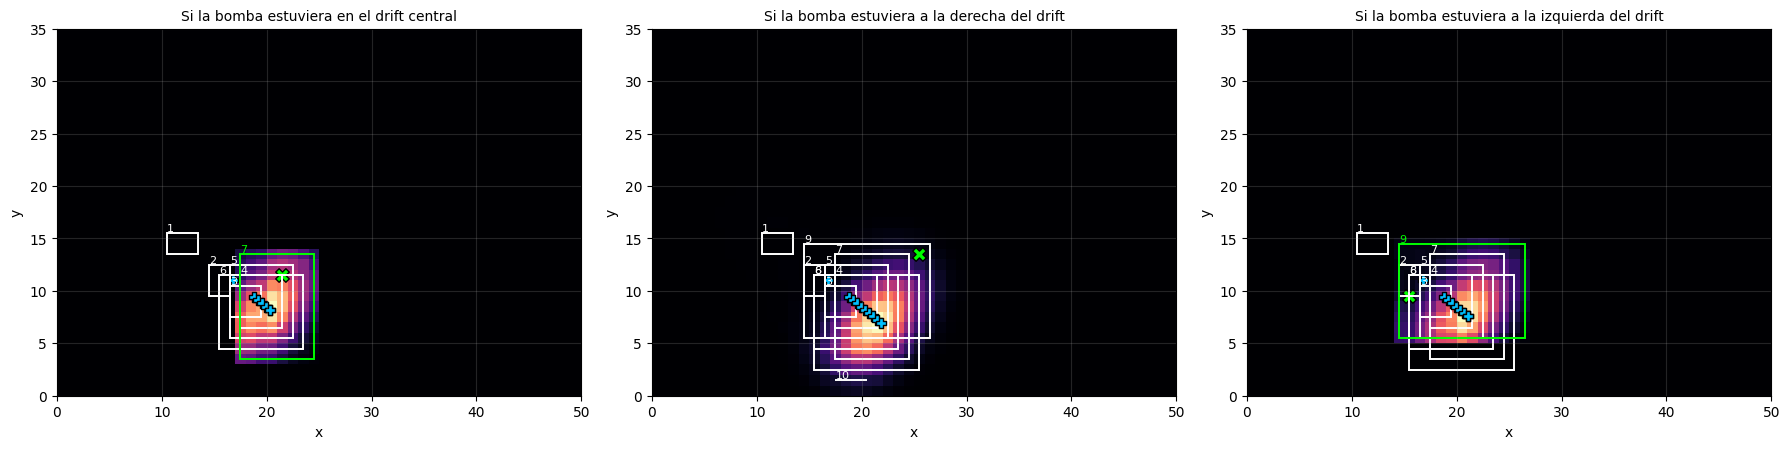

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (scenario, (label, df, trace, env)) in zip(axes, three_cases.items()):
    ax.imshow(grid.reshape_2d(trace[-1]), origin='lower', extent=[0, grid.Nx, 0, grid.Ny], cmap='magma')
    if len(df):
        true_cell = int(df.true_cell.iloc[0])
        ax.scatter(grid.x[true_cell], grid.y[true_cell], color='lime', marker='X', s=95, edgecolor='black', label='true cell')
        for _, r in df.iterrows():
            color = 'lime' if r.s_t == 1 else 'white'
            ax.add_patch(plt.Rectangle((r.x_min, r.y_min), r.x_max-r.x_min, r.y_max-r.y_min,
                                       edgecolor=color, facecolor='none', lw=1.4))
            ax.scatter(r.center_x, r.center_y, color='deepskyblue', marker='P', s=55, edgecolor='black')
            ax.text(r.x_min, r.y_max + 0.15, str(int(r.mission)), color=color, fontsize=8)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

### Reading the three operational cases

- In the **center** case the missions should sweep a band advancing along $d_{\mathrm{long}}$ with little lateral displacement.
- In the **right** case the inspection should be shifted towards the positive side of $d_{\mathrm{trans}}$.
- In the **left** case the inspection should be shifted towards the negative side of $d_{\mathrm{trans}}$.

When we do not know in advance which of the three scenarios is the real one, the recommended strategy is **`mixture`**: it combines the three lateral hypotheses with a small probability for the strong-wind variant, hedging across the physical possibilities suggested by the witnesses.